# Segmentation client : Online Retail Dataset (UK, 2010–2011)
## Objectif
L'objectif est d'identifier des classes de consommateurs à partir des transactions, pour adapter des stratégies marketing.

On veut identifier 3 classes de consommateurs pour proposer des offres adaptées.


### Informations générales
* **Type de données** : multivariées, séquentielles, séries temporelles  
* **Période** : 01/12/2010 → 09/12/2011  
* **Contexte** : Transactions d’un e-commerce britannique spécialisé dans les cadeaux  
* **Clients** : Particuliers et grossistes  
* **Nombre d’instances** : 541 909  
* **Nombre de variables** : 8 (dont ID, numériques et catégorielles)  
* **Valeurs manquantes** : Oui (notamment CustomerID).  


**Variable**  
| Variable     | Type          | Description                                                                 |
|--------------|--------------|-----------------------------------------------------------------------------|
| InvoiceNo    | Catégorielle | Identifiant unique de la transaction (6 chiffres). Préfixe "C" = annulation |
| StockCode    | Catégorielle | Identifiant unique du produit (5 chiffres)                                 |
| Description  | Catégorielle | Nom du produit                                                             |
| Quantity     | Entier       | Quantité d’articles achetés (par transaction)                              |
| InvoiceDate  | Date         | Date et heure de la transaction                                            |
| UnitPrice    | Réel         | Prix unitaire (£)                                                          |
| CustomerID   | Catégorielle | Identifiant unique du client (5 chiffres)                                  |
| Country      | Catégorielle | Pays du client                                                             |

## Chargement & aperçu des données

* Le dataset contient des transactions entre **2010-12-01 et 2011-12-09**.
* **Colonnes clés** : InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.
* On garde uniquement les lignes exploitables (pas d’annulations, quantités/prix strictement positifs, clients identifiés).

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [ ]:
# chemin absolu propre
ROOT = Path().resolve().parent 
DATA_PATH = ROOT / "data" / "Online_Retail.xlsx"
df = pd.read_excel(DATA_PATH)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# typage
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],dayfirst=True, errors="coerce")


## Nettoyage

* **Annulations** : **InvoiceNo** commmençant pas "C" à exclure
* **Quantités/UnitPrice**: retirer valeurs < 0
* **CustomeriD** : Garder uniquement les clients identifiés
* Dates invalides : drop 

In [ ]:
df = df.dropna(subset=["InvoiceDate"]) # dates valides
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

In [ ]:
len(df["InvoiceNo"].str.startswith("C"))

541909

In [ ]:
mask_cancel = df["InvoiceNo"].str.startswith("C", na=False)
mask_qty = df["Quantity"] > 0
mask_price = df["UnitPrice"] > 0
mask_cust = df["CustomerID"].notna()

In [ ]:
clean = df[~mask_cancel & mask_cust & mask_qty & mask_price].copy()
clean["CustomerID"] = clean["CustomerID"].astype(str)

print("Avant nettoyage", df.shape, "| après", clean.shape)

Avant nettoyage (541909, 8) | après (397884, 8)


## Feauture Engineering 

* **Montant**: somme (Quantity * UnitPrice) par client
* **Frequence** : nombre de facture distinct par client 
* **Recence** : nombre de jours depuis la dernier commande du client jusqu'à une date reference D_ref 
* On choisit Derf = max (Invoice Date) + 1 jour (fiable et independant d'un split train/test)

In [ ]:
from datetime import timedelta

In [ ]:
# Date de reference 
ref_date = clean["InvoiceDate"].max() + timedelta(days=1)

In [ ]:
# Montant par ligne 
clean["LineAmount"] = clean["Quantity"] * clean["UnitPrice"]

In [ ]:
# Agregation 
rfm= clean.groupby("CustomerID").agg(
    Montant = ("LineAmount", "sum"),
    Frequence = ("InvoiceNo", "nunique"),
    LastPurchase = ("InvoiceDate", "max"),
)
rfm 

,Montant,Frequence,LastPurchase
CustomerID,,,
12346.0,77183.60,1,2011-01-18 10:01:00
12347.0,4310.00,7,2011-12-07 15:52:00
12348.0,1797.24,4,2011-09-25 13:13:00
12349.0,1757.55,1,2011-11-21 09:51:00
12350.0,334.40,1,2011-02-02 16:01:00
...,...,...,...
18280.0,180.60,1,2011-03-07 09:52:00
18281.0,80.82,1,2011-06-12 10:53:00
18282.0,178.05,2,2011-12-02 11:43:00


In [ ]:
rfm["Recence"] = (ref_date - rfm["LastPurchase"]).dt.days
rfm = rfm.drop(columns=["LastPurchase"]).reset_index()


Text(0, 0.5, 'Nombre de client')

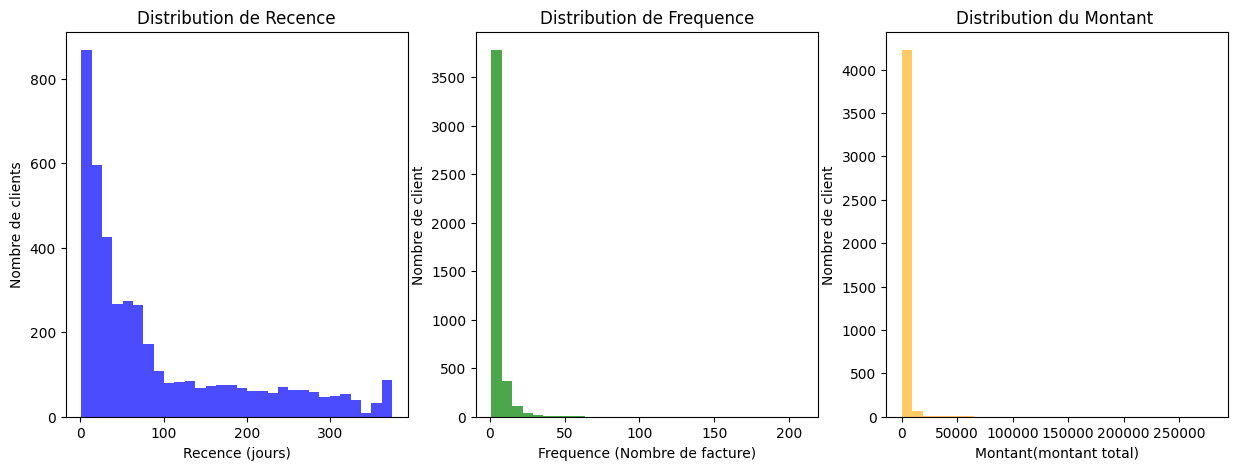

In [ ]:
# Dessiner les distribution de rfm pour voir s'il faut utiliser une transformation
fig, axes = plt.subplots(1,3, figsize = (15,5))
axes[0].hist(rfm["Recence"], bins=30, color='blue', alpha=0.7)
axes[0].set_title('Distribution de Recence')
axes[0].set_xlabel('Recence (jours)')
axes[0].set_ylabel('Nombre de clients')

axes[1].hist(rfm["Frequence"], bins = 30, color = 'green', alpha = 0.7)
axes[1].set_title('Distribution de Frequence')
axes[1].set_xlabel('Frequence (Nombre de facture)')
axes[1].set_ylabel('Nombre de client')

axes[2].hist(rfm["Montant"], bins=30, color="Orange", alpha=0.6)
axes[2].set_title("Distribution du Montant ")
axes[2].set_xlabel("Montant(montant total)")
axes[2].set_ylabel("Nombre de client")

Les distributions sont gaussien, sont asymetrique (queue lourde à gauche)

### Pretraitement des variables 

In [ ]:
rfm_log = rfm.copy()

for col in ["Recence", "Frequence", "Montant"]:
    rfm_log[col] = np.log1p(rfm_log[col])

Text(0, 0.5, 'Nombre de client')

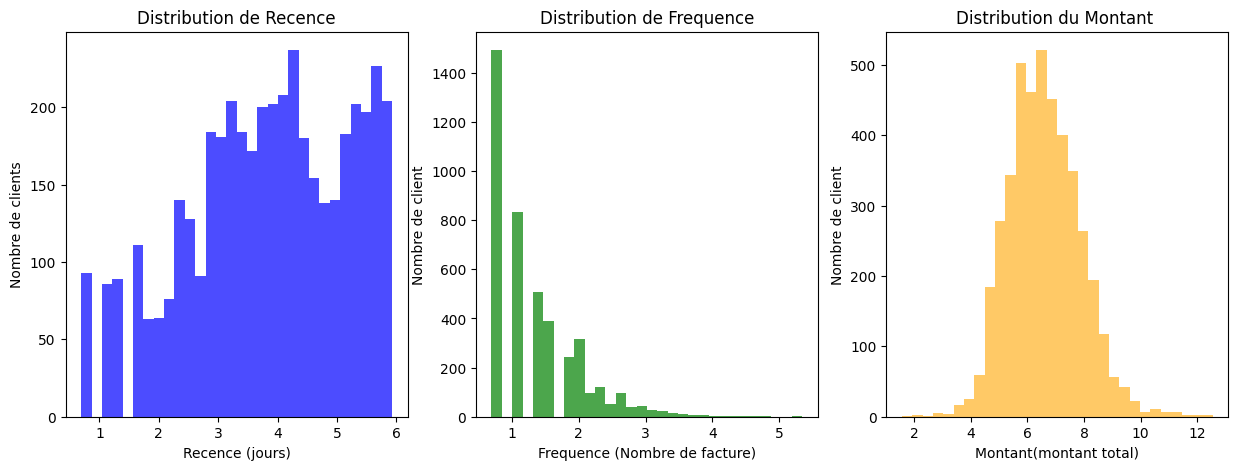

In [ ]:
# Dessiner les distribution de rfm pour voir s'il faut utiliser une transformation
fig, axes = plt.subplots(1,3, figsize = (15,5))
axes[0].hist(rfm_log["Recence"], bins=30, color='blue', alpha=0.7)
axes[0].set_title('Distribution de Recence')
axes[0].set_xlabel('Recence (jours)')
axes[0].set_ylabel('Nombre de clients')

axes[1].hist(rfm_log["Frequence"], bins = 30, color = 'green', alpha = 0.7)
axes[1].set_title('Distribution de Frequence')
axes[1].set_xlabel('Frequence (Nombre de facture)')
axes[1].set_ylabel('Nombre de client')

axes[2].hist(rfm_log["Montant"], bins=30, color="Orange", alpha=0.6)
axes[2].set_title("Distribution du Montant ")
axes[2].set_xlabel("Montant(montant total)")
axes[2].set_ylabel("Nombre de client")

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log[["Recence", "Frequence", "Montant"]])

## Choix du Nombre de Cluster 
On entraîne KMeans, puis on profite des centroide pour interpreter les profils

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
k_value = 3 
kmeans = KMeans(n_clusters=k_value, n_init=10)
labels = kmeans.fit_predict(X)

rfm["Cluster"] = labels
rfm.head()

,CustomerID,Montant,Frequence,Recence,Cluster
0,12346.0,77183.60,1,326,1
1,12347.0,4310.00,7,2,2
2,12348.0,1797.24,4,75,1
3,12349.0,1757.55,1,19,1
4,12350.0,334.40,1,310,0


Profiling des clusters 
* **Centroide** (dans l'espace transformé) alors on inverse les étapes (inverse-standardisation + expm1) pour revenir à l'echelle RFM d'origine.
* **KPIs** par cluster : taille, valeur moyenne/medianes, par du CA.

In [ ]:
# Centroide dans l'espace log-standardisé ->
centroids_std = kmeans.cluster_centers_
centroids_log = scaler.inverse_transform(centroids_std)

centroids = pd.DataFrame(centroids_log, columns=["Recence", "Frequence", "Montant"])
for col in ["Recence", "Frequence", "Montant"]:
    centroids[col] = np.expm1(centroids[col]) # inverse de log1p
    
centroids["Cluster"]=range(k_value)
centroids = centroids.set_index("Cluster")

In [ ]:
# KPis par cluster
cluster_stats = rfm.groupby("Cluster").agg(
    n_clients=("CustomerID", "count"),
    Recence_median=("Recence", "median"),
    Frequence_median=("Frequence", "median"),
    Montant_median=("Montant", "median"),
    Montant_sum=("Montant", "sum"),
).sort_values("Montant_sum", ascending=False)

total_Montant = cluster_stats["Montant_sum"].sum()
cluster_stats["Part_du_CA_%"] = (cluster_stats["Montant_sum"]/total_Montant * 100).round(2)

In [ ]:
print("\n === Centroides (echelle RFM originale) ===")
display(centroids.round(2))

print("\n=== KPIs par cluster ===")
display(cluster_stats.round(2))



 === Centroides (echelle RFM originale) ===


,Recence,Frequence,Montant
Cluster,,,
0,127.91,1.28,273.94
1,28.49,3.10,956.51
2,9.24,10.68,4273.94



=== KPIs par cluster ===


,n_clients,Recence_median,Frequence_median,Montant_median,Montant_sum,Part_du_CA_%
Cluster,,,,,,
2,769,9.0,10.0,3707.12,6081985.69,68.25
1,1697,30.0,3.0,979.26,2150751.80,24.13
0,1872,158.0,1.0,298.06,678670.41,7.62


## Interpretation marketing des clusters 

**Le cluster 2** correspond aux client les plus précieux : 
* Ils ont achété très récemment (Recence = 9 jours)
* Commandent très souvent (Frequences = 11)
* Dépensent beaucoup (Montant = 3708.34 euros)

Bien qu'ils ne représentnt qu'environ 766 clients, ils générent plus de 68% du chiffre d'affaire. Ce sont les VIP hyper-actifs, La strategie doit viser à les fideliser au maximum : accès anticipé aux nouveautés, bundles premium, programmes de fidelité exclusifs, offres personnalisées et suivi rapproché pour eviter toute attribution

------
**Le cluster 1** regroupe le coeur de clientèle : 
* Des clients encore assez récents(Recence = 28 jours)
* Une fréquence modéré (= 3 commandes)
* Une dépense moyenne (980.74 euros)

ils sont près de **1700** et contribuent à environ **24%** du chiffre d'affaire. Ce segment est strategique pour consolider la base : actions de nurturing recommandations personnalisées, incitations à la récurence (par exemple via le free shipping au-dessus d'un certain seuil), et campagnes ciblées pour transformer ces clients en reguliers. 

-----

**Le cluster 0** rassemble les **clients les moins engagées**

*  Achats anciens (Recence = 128 jours)
*  Très peu frequences (= 1 commande)
*  Dépense faible (290 euros)

C'est pourtant le segment le plus larges (= 1870 clients), mais il ne génere que 7.62 % du chiffre d'affaires. Ce sont les clients **dormants ou occasionnels**. Les efforts doivent être calibrés : campagnes de réactivation (offre limitées dans le temps, emails), mise en avant des best-sellers, rappels saisonniers.
L'investissement marketing doit être controler pour eviter un coût d'acquisition superieur à la valeur récuperée 